In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
L = 1.0
Nx = 100
dx = L / Nx
phi = 0.2
u = 1e-6
mu_w = 1e-3
mu_g = 1e-5
S_wc = 0.2
S_gr = 0.1

S_left = 0.9

In [4]:
u0s = [lambda x: x * 0 + 0.2, lambda x: x * 0 + 0.4, lambda x: x * 0 + 0.7]

In [5]:
def S_n(S):
    return (S - S_wc) / (1 - S_wc - S_gr)

def k_rw(S):
    return ((S - S_wc) / (1 - S_wc - S_gr)) ** 4

def k_rg(S):
    return ((1 - S - S_gr) / (1 - S_wc - S_gr)) ** 2

def f(S):
    lambda_w = k_rw(S) / mu_w
    lambda_g = k_rg(S) / mu_g
    return lambda_w / (lambda_w + lambda_g)

def rhs(t, y):
    F = np.empty(y.shape[0] + 1, dtype=np.float32)
    F[0] = f(S_left)
    F[1:] = f(y)

    return -(F[1:] - F[:-1]) / dx
    

In [6]:
def f_tilde(S):
    return S_n(S)

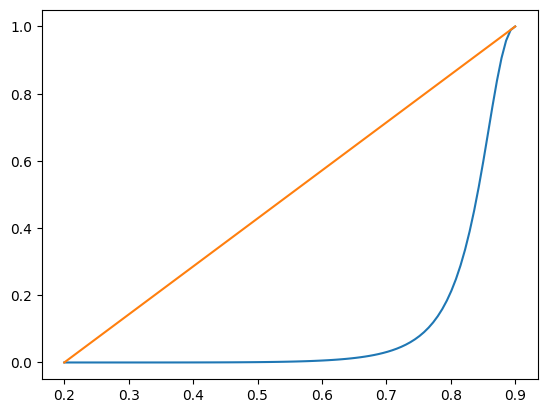

In [7]:
plt.plot(torch.linspace(0.2, 0.9, 100), f(torch.linspace(0.2, 0.9, 100)))
plt.plot(torch.linspace(0.2, 0.9, 100), f_tilde(torch.linspace(0.2, 0.9, 100)))
plt.show()

In [8]:
dt = 150.0 / (phi / u)
T_max = 150000 / (phi / u)
Nt = np.ceil(T_max / dt)

N_plot = 5000

idxs_t = np.random.randint(low=0, high=Nt, size=N_plot)
idxs_x = np.random.randint(low=0, high=Nx, size=N_plot)

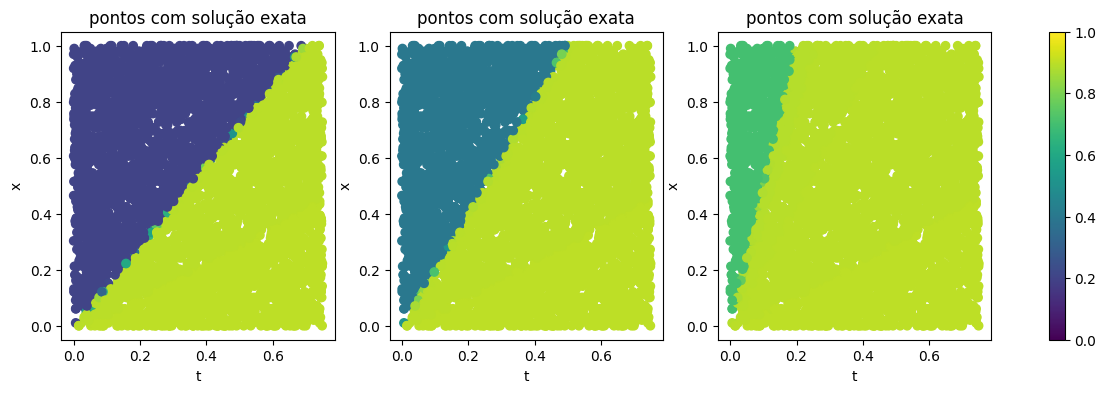

In [9]:
cols = min(3, len(u0s))
rows = np.ceil(len(u0s) / cols).astype(int)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.atleast_1d(axes).flatten()

uss = list()

for i, u0 in enumerate(u0s):
    xs = np.linspace(0, L, Nx)
    S0 = u0(xs)
    
    ts, us = ODE_system_solver(rhs, S0, 0, T_max, dt)
    uss.append(us)
    
    X_plot = np.stack((ts[idxs_t], xs[idxs_x]), axis=1)
    u_plot = us[idxs_t, idxs_x]

    sc = axes[i].scatter(X_plot[:, 0], X_plot[:, 1], c=u_plot, cmap="viridis", vmin=0, vmax=1)
    axes[i].set_xlabel('t')
    axes[i].set_ylabel('x')
    axes[i].set_title('pontos com solução exata')
    
cbar = fig.colorbar(sc, ax=axes, orientation='vertical')

In [10]:
def sample_points(N_colocacao, N_contorno, N_inicial, max_t = T_max):
    X_colocacao = torch.cat([
        (1 - torch.rand(N_colocacao, 1)) * max_t,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        (1 - torch.rand(N_contorno, 1)) * max_t, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

def resample_ozanski(X_colocacao, X_contorno, X_inicial, u0, model, perc=0.15, perc_boundary=0.1, lambda_1=0.1, max_t = T_max):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, u0, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary), max_t)

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial


In [11]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, u0, lambda_1 = 1.5, make_reduction=True):
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]

    # use f_tilde (https://arxiv.org/pdf/2112.14826)
    f_val = f_tilde(y_fake)
    df_dy = torch.autograd.grad(f_val, y_fake, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, :1]
    dy_dx = dy_dX[:, 1:]
    df_dx = df_dy * dy_dx # regra da cadeia

    if make_reduction:
        L_f = torch.mean((dy_dt + df_dx) ** 2)
        L_b1 = torch.mean((y_inicial - u0(X_inicial)) ** 2)
        L_b2 = torch.mean((y_contorno - 0.9) ** 2)
    
        return L_f + lambda_1 * (L_b1 + L_b2)
    else:
        L_f = (dy_dt + df_dx) ** 2
        L_b1 = (y_inicial - u0(X_inicial)) ** 2
        L_b2 = (y_contorno - 0.9) ** 2

        return L_f, L_b1, L_b2

In [12]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
    def forward(self, z):
        scale = torch.tensor([T_max, 1.0])
        z_normalized = z / scale
        return self.net(z_normalized)

In [13]:
N_colocacao = 3000
N_contorno = 500
N_inicial = 500

# pontos usados (escolhidos aleatoriamente a cada passo de treino)
X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

batch_size = 256
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(2, 1, 32)

n_iter = 10000
lr = 1e-3
optimizer = optim.Adam(PINN_model.parameters(), lr=lr)

# a cada quantas iterações vamos alterar os pontos usados
N_change_points = 75

In [14]:
for it in range(n_iter):

    X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
    X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
    X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
    u0 = u0s[0] # random.choice(u0s)

    # branch net stuff...
    
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)
    
    y_fake = PINN_model(X_batch)

    # dot with branch output...
    
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, X_batch_contorno, y_fake_contorno, X_batch_inicial, y_fake_inicial, u0)
    
    optimizer.zero_grad()
    L_PINN.backward()
    optimizer.step()
    

    if it % N_change_points == 0:
        X_colocacao, X_contorno, X_inicial = resample_ozanski(X_colocacao, X_contorno, X_inicial, u0, PINN_model)
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_PINN={L_PINN.item():.10f}")

Iter 1000: L_PINN=0.0101900715
Iter 2000: L_PINN=0.0024974484
Iter 3000: L_PINN=0.0094993869
Iter 4000: L_PINN=0.0507071875
Iter 5000: L_PINN=0.0455766656
Iter 6000: L_PINN=0.0022751854
Iter 7000: L_PINN=0.0002422717
Iter 8000: L_PINN=0.0006055480
Iter 9000: L_PINN=0.0006963538
Iter 10000: L_PINN=0.0035414507


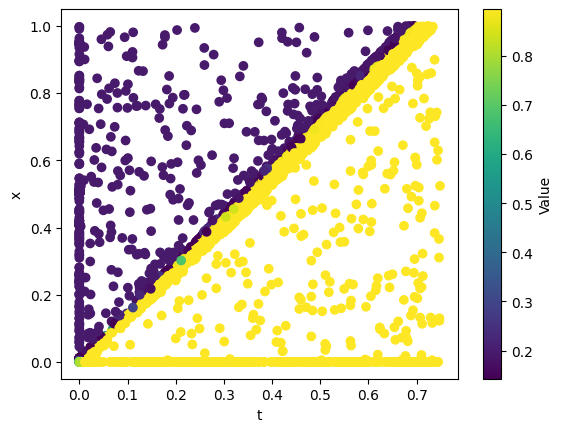

In [15]:
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))

y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

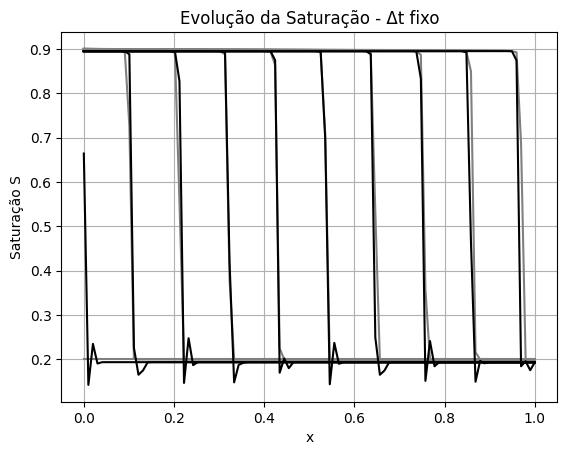

In [16]:
for idx, t in enumerate(ts[::100]):
    X = torch.tensor(np.stack([np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = PINN_model(X).detach().cpu().numpy()

    # print(xs.shape, us[t].shape)
    plt.plot(xs, uss[0][idx * 100, :], label=f't = {t/3600:.1f} h', color="gray")
    plt.plot(xs, S, label=f't = {t/3600:.1f} h', color="black")

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
# plt.legend()
plt.grid(True)
plt.show()